In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from turbos.sim.p3d.p3d_2 import P3D
import matplotlib.pyplot as plt

In [3]:

run = P3D(
    "/archive/tulasi/MEGARUNS_DATA_SUBSET/149p6",
    filenum="000",
)
#419
ds = run.load_xarray(419, variables=['Pe', 'ue', 'Pi', 'ui', 'J'])
print(ds)

<xarray.Dataset> Size: 2GB
Dimensions:  (x: 4096, y: 4096, j: 3, i: 3, c: 3)
Coordinates:
  * x        (x) float64 33kB 0.0 0.03652 0.07305 0.1096 ... 149.5 149.5 149.6
  * y        (y) float64 33kB 0.0 0.03652 0.07305 0.1096 ... 149.5 149.5 149.6
  * j        (j) <U1 12B 'x' 'y' 'z'
  * i        (i) <U1 12B 'x' 'y' 'z'
  * c        (c) <U1 12B 'x' 'y' 'z'
Data variables:
    Pe       (x, y, i, j) float32 604MB 0.3033 -0.007991 ... 0.0205 0.403
    ue       (x, y, c) float32 201MB 0.01591 0.0244 ... 0.04151 -0.009202
    Pi       (x, y, i, j) float32 604MB 0.3142 -0.01473 ... -0.01141 0.3694
    ui       (x, y, c) float32 201MB 0.04301 0.02117 -0.1289 ... 0.01257 -0.1358
    J        (x, y, c) float32 201MB 0.03226 -0.01035 ... -0.04091 -0.1015
Attributes:
    time:      209.5
    run:       149p6
    snapshot:  419
    format:    hdf5


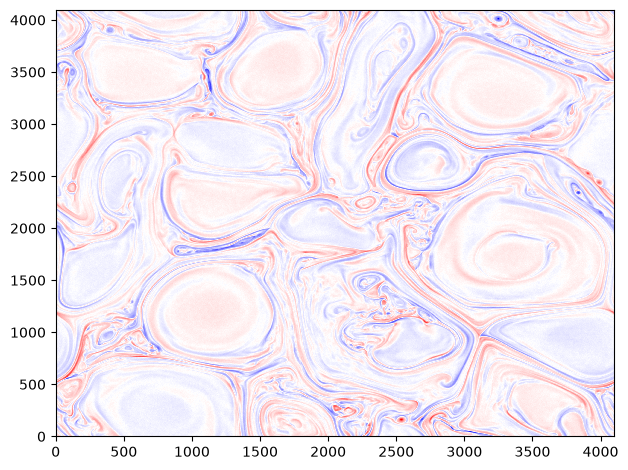

In [4]:
f, ax = plt.subplots(1,1, sharey= True)
vm = 1.5

jz = ds['J'].sel(c = 'z').transpose()
c0 = ax.pcolormesh(jz, cmap= 'bwr', vmin = -vm, vmax = vm)

plt.tight_layout()
plt.show()

In [5]:
from turbos.filter import kfilter
ds['Pe'] = kfilter(ds['Pe'], 13)
ds['ue'] = kfilter(ds['ue'], 13)
ds['Pi'] = kfilter(ds['Pi'], 13)
ds['ui'] = kfilter(ds['ui'], 13)

In [6]:
from turbos.pressure_strain import pressure_strain

ds['PiDe'] = pressure_strain(ds['Pe'], ds['ue'])['PiD']

ds['PiDi'] = pressure_strain(ds['Pi'], ds['ui'])['PiD']


In [7]:
import numpy as np

print('Pide=', np.mean(ds['PiDe'].values))
print('Pidi=', np.mean(ds['PiDi'].values))

Pide= 7.262516413935146e-05
Pidi= 6.767004208298247e-05


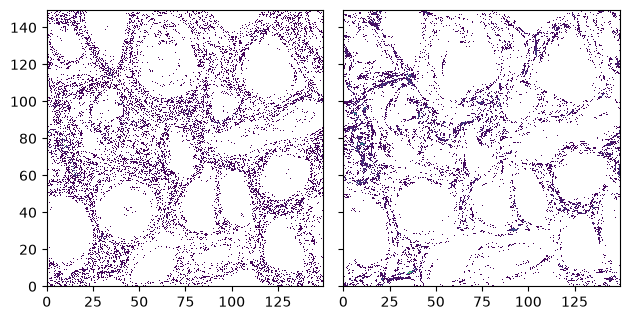

In [9]:
f, ax = plt.subplots(1,2, sharey= True)

thr1 = 1e-3
thr2 = 5e-4

cmap = plt.colormaps["viridis"].with_extremes(under="white", over="red")


pide_thr = ds["PiDe"].where(
    np.abs(ds["PiDe"]) > thr1
)


pidi_thr = ds["PiDi"].where(
    np.abs(ds["PiDi"]) > thr2
)

xx = ds["x"].values
c0 = ax[0].pcolormesh(xx, xx, pide_thr, cmap= cmap, vmin = thr1)
# c0.set_clim(-0.005, 0.005)
# ax[0].set_box_aspect(1)

c1 = ax[1].pcolormesh(xx, xx, pidi_thr, cmap= cmap, vmin = thr2)
# c1.set_clim(-0.005, 0.005)
# f.colorbar(c1, ax=ax[1])
# ax[1].set_box_aspect(1)
for a in ax:
    a.set_aspect('equal')
plt.tight_layout()
plt.show()